# **Image Classification Using Pre-trained Models**
**Laboratory Activity 6:** *Model Inference on Custom Dataset*
___

This laboratory focuses on applying pre-trained image classification models from PyTorch to a custom image dataset. The activity involves preparing and loading the dataset, performing model inference, evaluating model performance using classification metrics, and comparing the results of several pre-trained architectures.

## **Objectives**

By the end of this laboratory, the student should be able to:

- prepare an image dataset for classification;
- perform image classification using pre-trained PyTorch models; and
- evaluate and compare the performance of different models.

## **Laboratory Problem**
**Instruction:** 
- Look for a suitable **image classification dataset**, or create your own **custom dataset** following the procedure demonstrated during the previous class discussion.
- Curate and organize the dataset appropriately for an image classification task.
- Create a custom PyTorch **`Dataset` class** to load and process the curated dataset.
- Create appropriate **`DataLoader` objects** for loading the dataset in batches for model evaluation.
- Perform **model inference** using different trained/pre-trained models available from **`torchvision.models`**.
- Evaluate and compare **up to five (5) different models** using appropriate performance metrics, such as **accuracy, precision, recall, and F1-score**.
- Present the comparison of the models clearly using a **table and/or appropriate visualizations**.
- Write a **short analysis and conclusion** discussing the results. Explain possible reasons why the models produced different levels of performance, considering factors such as model architecture, model complexity, input requirements, and suitability for the selected dataset.

## **Dataset Preparation**

The **EuroSAT** dataset is used for this laboratory. It is an RGB satellite-image dataset for land-use and land-cover classification. It contains **27,000 images** distributed across **10 classes**:

AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, and SeaLake.

The original RGB images are 64 × 64 pixels. They are resized to 224 × 224 pixels for compatibility with the selected ImageNet-pre-trained models.

### **Dataset Structure**

```text
data/
└── eurosat/
    └── 2750/
        ├── AnnualCrop/
        ├── Forest/
        ├── HerbaceousVegetation/
        ├── Highway/
        ├── Industrial/
        ├── Pasture/
        ├── PermanentCrop/
        ├── Residential/
        ├── River/
        └── SeaLake/
```

Each folder represents one classification category.

## **Implementation**

### **Import Required Libraries**

In [1]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision.datasets import EuroSAT
from torchvision import transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    densenet121, DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
    squeezenet1_1, SqueezeNet1_1_Weights
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available.")
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    device = torch.device("cpu")
    print("CUDA is not available.")
    print("Using CPU.")

print("Selected device:", device)

CUDA is available.
GPU: NVIDIA GeForce RTX 3050
CUDA version: 12.8
Selected device: cuda


### **Download and Prepare the Dataset**

In [3]:
_ = EuroSAT(root="data", download=True)

DATA_DIR = Path("data/eurosat/2750")

print("Dataset directory:", DATA_DIR)
print("Directory exists:", DATA_DIR.exists())

Dataset directory: data\eurosat\2750
Directory exists: True


### **Explore Dataset Classes**

In [4]:
class_names = sorted([
    folder.name for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(class_names))
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

Number of classes: 10
0: AnnualCrop
1: Forest
2: HerbaceousVegetation
3: Highway
4: Industrial
5: Pasture
6: PermanentCrop
7: Residential
8: River
9: SeaLake


In [5]:
class_counts = {
    class_name: len(list((DATA_DIR / class_name).glob("*.jpg")))
    for class_name in class_names
}

pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

,Class,Number of Images
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


### **Visualize Sample Images**

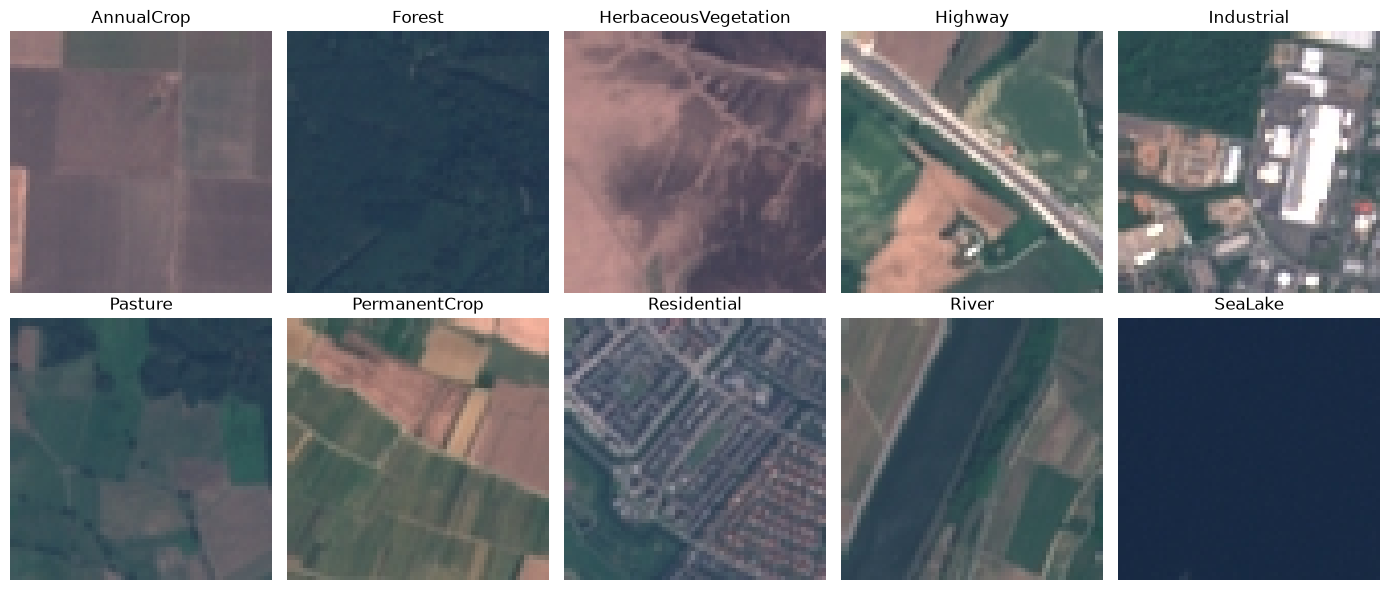

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, class_name in zip(axes.ravel(), class_names):
    image_path = next((DATA_DIR / class_name).glob("*.jpg"))
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

### **Define Image Transformations**

The images are resized to 224 × 224 pixels, converted to tensors, and normalized using the values commonly used by ImageNet-pre-trained models.

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### **Create the Custom Dataset Class**

In [8]:
class EuroSATCustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.classes = sorted([
            folder.name for folder in self.root_dir.iterdir()
            if folder.is_dir()
        ])

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.classes)
        }

        self.samples = []

        for class_name in self.classes:
            class_dir = self.root_dir / class_name
            for image_path in sorted(class_dir.glob("*.jpg")):
                self.samples.append(
                    (image_path, self.class_to_idx[class_name])
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
dataset = EuroSATCustomDataset(
    root_dir=DATA_DIR,
    transform=transform
)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)

Number of images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### **Verify the Class Mapping**

In [10]:
dataset.class_to_idx

{'AnnualCrop': 0,
 'Forest': 1,
 'HerbaceousVegetation': 2,
 'Highway': 3,
 'Industrial': 4,
 'Pasture': 5,
 'PermanentCrop': 6,
 'Residential': 7,
 'River': 8,
 'SeaLake': 9}

### **Create the DataLoaders**

The dataset is divided into **70% training**, **15% validation**, and **15% test** sets. Stratification keeps the class proportions similar across the subsets.

In [11]:
indices = np.arange(len(dataset))
labels = np.array([label for _, label in dataset.samples])

train_idx, temp_idx, _, temp_labels = train_test_split(
    indices,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Training images: 18900
Validation images: 4050
Test images: 4050


In [12]:
batch_size = 32
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=0, pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=pin_memory
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 591
Validation batches: 127
Test batches: 127


### **Verify DataLoader Output**

In [13]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image batch dtype:", images.dtype)
print("Label batch dtype:", labels.dtype)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image batch dtype: torch.float32
Label batch dtype: torch.int64


### **Load the Pre-trained Models**

Five models from `torchvision.models` are compared.

| Model | Main characteristic |
|---|---|
| **ResNet18** | Uses residual connections |
| **DenseNet121** | Reuses features through dense connections |
| **EfficientNet-B0** | Balances model size and performance |
| **MobileNetV3-Small** | Lightweight and computationally efficient |
| **SqueezeNet1_1** | Compact architecture |

The pre-trained feature-extraction layers are frozen, while the original ImageNet classifier is replaced with a new classifier containing 10 outputs for EuroSAT.

In [14]:
NUM_CLASSES = len(dataset.classes)

def create_model(model_name):
    if model_name == "ResNet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    elif model_name == "DenseNet121":
        model = densenet121(weights=DenseNet121_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        model.classifier = nn.Linear(
            model.classifier.in_features, NUM_CLASSES
        )

    elif model_name == "EfficientNet-B0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features, NUM_CLASSES
        )

    elif model_name == "MobileNetV3-Small":
        model = mobilenet_v3_small(
            weights=MobileNet_V3_Small_Weights.DEFAULT
        )
        for p in model.parameters():
            p.requires_grad = False
        model.classifier[3] = nn.Linear(
            model.classifier[3].in_features, NUM_CLASSES
        )

    elif model_name == "SqueezeNet1_1":
        model = squeezenet1_1(weights=SqueezeNet1_1_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        model.classifier[1] = nn.Conv2d(
            512, NUM_CLASSES, kernel_size=1
        )
        model.num_classes = NUM_CLASSES

    else:
        raise ValueError("Unknown model name.")

    return model.to(device)

### **Train the Classification Layer**

Only the newly added classification layer is trained. The pre-trained feature extractor remains frozen. The model with the best validation accuracy is retained.

In [15]:
def train_model(model, epochs=5):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = 0.0

    history = {"train_accuracy": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            predictions = outputs.argmax(dim=1)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        train_accuracy = train_correct / train_total

        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                predictions = model(images).argmax(dim=1)
                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)

        val_accuracy = val_correct / val_total

        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Validation Accuracy: {val_accuracy:.4f}"
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history, best_val_accuracy

### **Perform Model Inference**

In [16]:
def perform_inference(model):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            predictions = model(images).argmax(dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())

    return y_true, y_pred

### **Evaluate Model Performance**

In [17]:
def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "F1-score": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }

### **Compare the Models**

In [18]:
model_names = [
    "ResNet18",
    "DenseNet121",
    "EfficientNet-B0",
    "MobileNetV3-Small",
    "SqueezeNet1_1"
]

results = []
histories = {}
predictions = {}

for model_name in model_names:
    print("\n" + "=" * 60)
    print("MODEL:", model_name)
    print("=" * 60)

    model = create_model(model_name)

    model, history, best_val_accuracy = train_model(
        model, epochs=5
    )

    y_true, y_pred = perform_inference(model)
    metrics = calculate_metrics(y_true, y_pred)

    metrics["Model"] = model_name
    metrics["Best Validation Accuracy"] = best_val_accuracy

    results.append(metrics)
    histories[model_name] = history
    predictions[model_name] = (y_true, y_pred)

    print(f"Test Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Test F1-score: {metrics['F1-score']:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


MODEL: ResNet18
Epoch 1/5 | Train Accuracy: 0.8242 | Validation Accuracy: 0.9081
Epoch 2/5 | Train Accuracy: 0.8934 | Validation Accuracy: 0.9136
Epoch 3/5 | Train Accuracy: 0.9038 | Validation Accuracy: 0.9158
Epoch 4/5 | Train Accuracy: 0.9119 | Validation Accuracy: 0.9160
Epoch 5/5 | Train Accuracy: 0.9130 | Validation Accuracy: 0.9247
Test Accuracy: 0.9259
Test F1-score: 0.9262

MODEL: DenseNet121
Epoch 1/5 | Train Accuracy: 0.8450 | Validation Accuracy: 0.9141
Epoch 2/5 | Train Accuracy: 0.9086 | Validation Accuracy: 0.9220
Epoch 3/5 | Train Accuracy: 0.9246 | Validation Accuracy: 0.9269
Epoch 4/5 | Train Accuracy: 0.9261 | Validation Accuracy: 0.9368
Epoch 5/5 | Train Accuracy: 0.9298 | Validation Accuracy: 0.9420
Test Accuracy: 0.9417
Test F1-score: 0.9412

MODEL: EfficientNet-B0
Epoch 1/5 | Train Accuracy: 0.8286 | Validation Accuracy: 0.9005
Epoch 2/5 | Train Accuracy: 0.8834 | Validation Accuracy: 0.9156
Epoch 3/5 | Train Accuracy: 0.8926 | Validation Accuracy: 0.9217
Epoch 

### **Model Comparison Table**

In [19]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Best Validation Accuracy"
    ]
]

results_df

,Model,Accuracy,Precision,Recall,F1-score,Best Validation Accuracy
0,ResNet18,0.925926,0.927223,0.925926,0.926184,0.924691
1,DenseNet121,0.941728,0.942694,0.941728,0.941238,0.941975
2,EfficientNet-B0,0.924691,0.924817,0.924691,0.924271,0.927654
3,MobileNetV3-Small,0.934074,0.933764,0.934074,0.933786,0.936543
4,SqueezeNet1_1,0.941975,0.942174,0.941975,0.941905,0.937531


### **Model Performance Visualization**

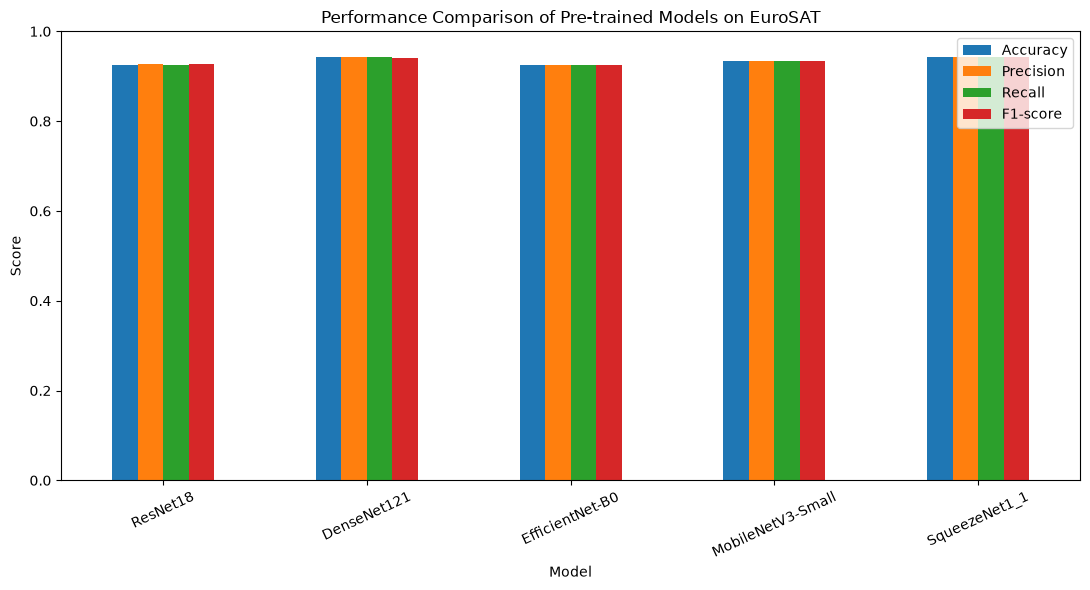

In [20]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Performance Comparison of Pre-trained Models on EuroSAT")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### **Training and Validation Accuracy**

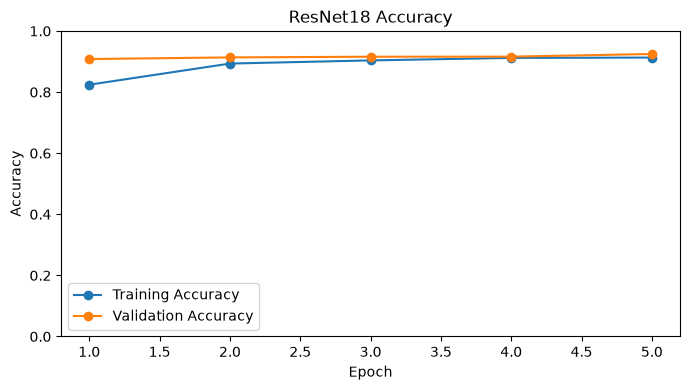

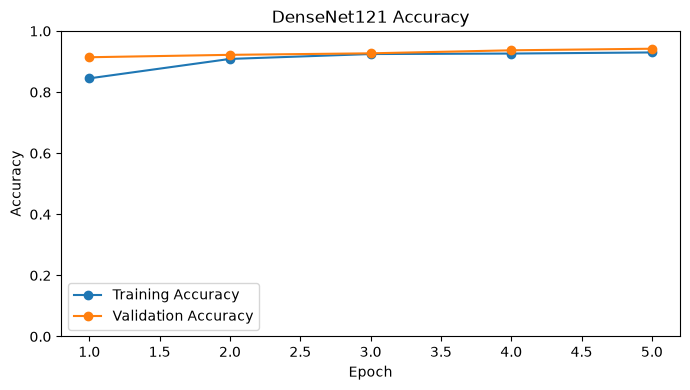

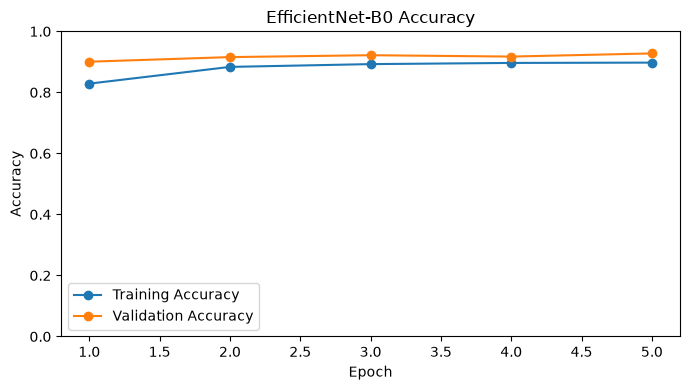

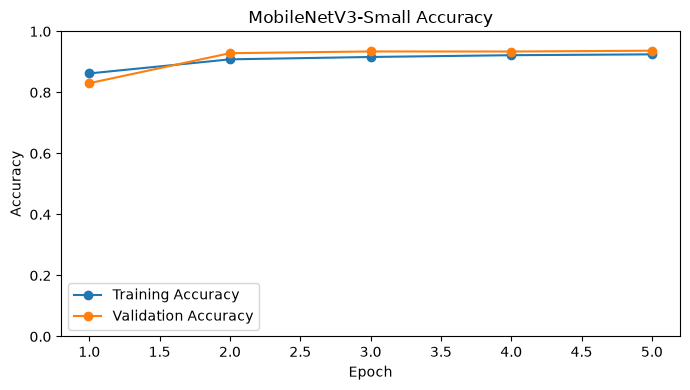

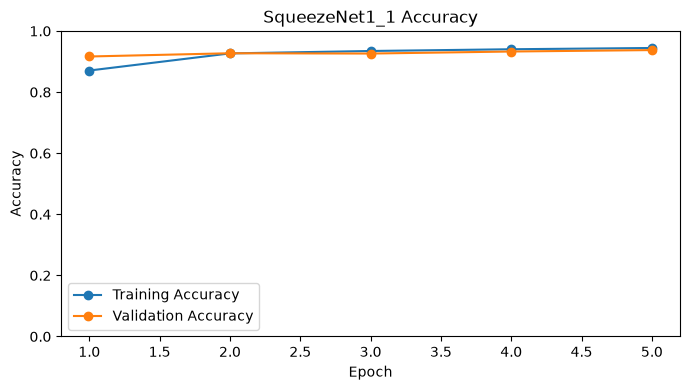

In [21]:
for model_name, history in histories.items():
    epochs_range = range(1, len(history["train_accuracy"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(
        epochs_range,
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy"
    )
    plt.plot(
        epochs_range,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

### **Confusion Matrix**

The confusion matrix of the model with the highest weighted F1-score is shown below. It provides a class-level view of correct predictions and misclassifications.

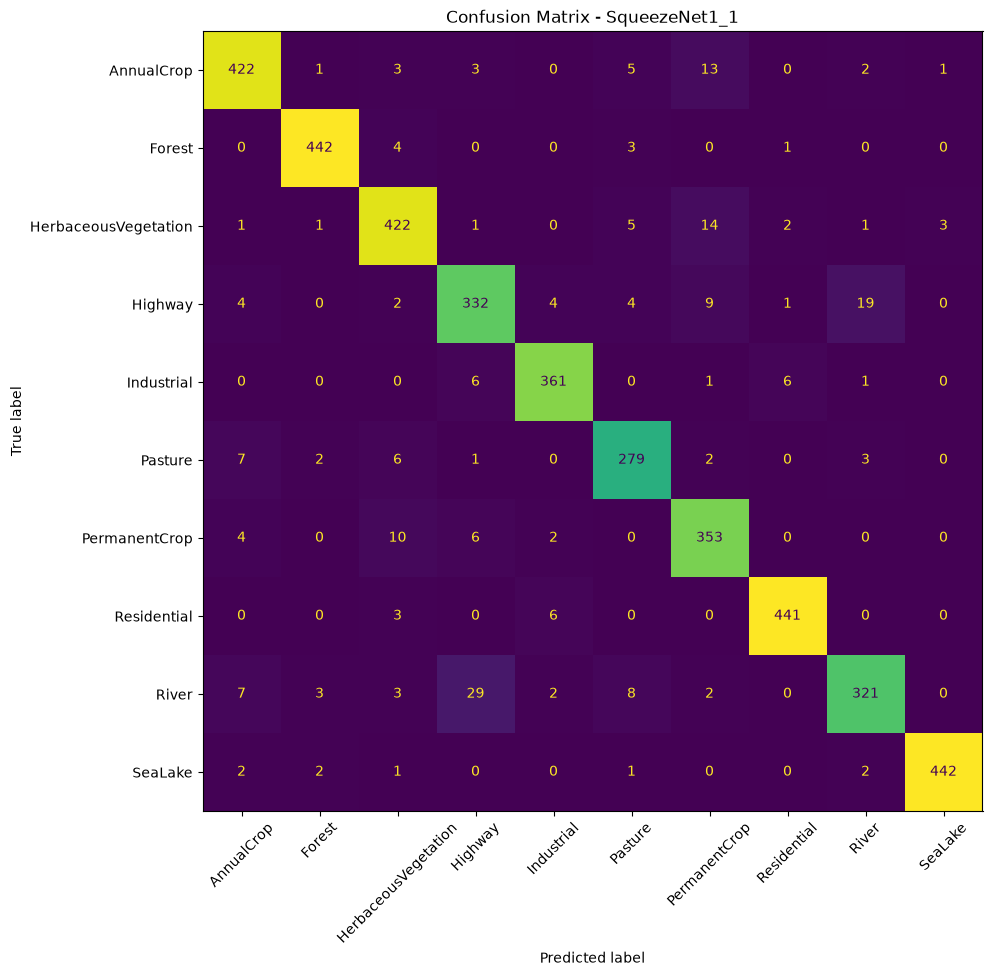

Model shown: SqueezeNet1_1


In [22]:
best_model_name = results_df.loc[
    results_df["F1-score"].idxmax(), "Model"
]

best_y_true, best_y_pred = predictions[best_model_name]

cm = confusion_matrix(best_y_true, best_y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

print("Model shown:", best_model_name)

### **Visualize Predictions of the Best Model**

The model with the highest F1-score is selected from the results already obtained above. The displayed images come from the first test batch. Because `test_loader` uses `shuffle=False`, the first predictions stored during evaluation correspond to this same batch.

In [23]:
# Select the model with the highest F1-score
best_model_name = results_df.loc[
    results_df["F1-score"].idxmax(),
    "Model"
]

best_y_true, best_y_pred = predictions[best_model_name]

print("Best-performing model:", best_model_name)
print(f"Test F1-score: {results_df.loc[results_df['Model'] == best_model_name, 'F1-score'].iloc[0]:.4f}")

Best-performing model: SqueezeNet1_1
Test F1-score: 0.9419


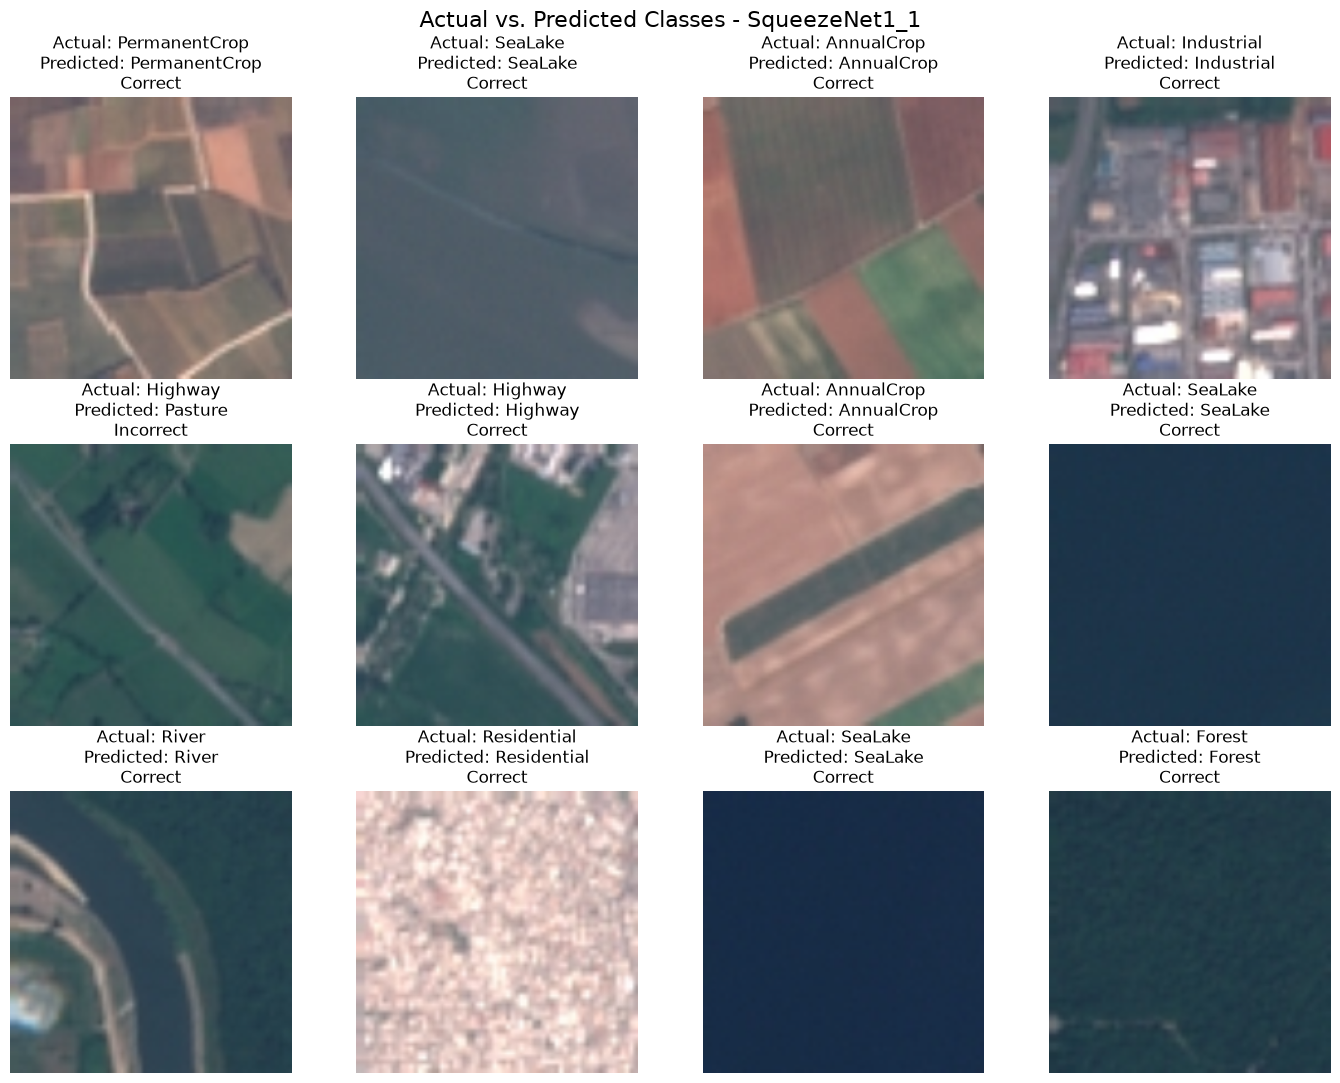

In [24]:
# Get one test batch for visualization
images, labels = next(iter(test_loader))

batch_predictions = best_y_pred[:len(labels)]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, 4, figsize=(14, 11))

for i, ax in enumerate(axes.ravel()):
    image = images[i].numpy().transpose(1, 2, 0)

    # Undo normalization for display
    image = image * std + mean
    image = np.clip(image, 0, 1)

    actual_class = dataset.classes[
        labels[i].item()
    ]

    predicted_class = dataset.classes[
        batch_predictions[i]
    ]

    result = (
        "Correct"
        if actual_class == predicted_class
        else "Incorrect"
    )

    ax.imshow(image)

    ax.set_title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"{result}"
    )

    ax.axis("off")

plt.suptitle(
    f"Actual vs. Predicted Classes - {best_model_name}",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [25]:
correct_count = sum(
    actual == predicted
    for actual, predicted in zip(
        labels.cpu().numpy(),
        batch_predictions
    )
)

incorrect_count = len(labels) - correct_count

print("Images shown:", len(labels))
print("Correct predictions:", correct_count)
print("Incorrect predictions:", incorrect_count)

print(
    "\nNote: these counts are only for the displayed test batch, "
    "not for the complete test set."
)

Images shown: 32
Correct predictions: 31
Incorrect predictions: 1

Note: these counts are only for the displayed test batch, not for the complete test set.


## **Results and Discussion**

The five pre-trained models achieved high classification performance on the EuroSAT test set. The results were:

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| ResNet18 | 92.59% | 92.72% | 92.59% | 92.62% |
| DenseNet121 | 94.17% | 94.27% | 94.17% | 94.12% |
| EfficientNet-B0 | 92.47% | 92.48% | 92.47% | 92.43% |
| MobileNetV3-Small | 93.41% | 93.38% | 93.41% | 93.38% |
| SqueezeNet1_1 | **94.20%** | **94.22%** | **94.20%** | **94.19%** |

Among the five models, **SqueezeNet1_1 obtained the highest accuracy and F1-score**, although its performance was very close to DenseNet121. DenseNet121 also performed strongly, while ResNet18, EfficientNet-B0, and MobileNetV3-Small obtained slightly lower scores.

The results show that the models were able to classify the EuroSAT images effectively, but their performance was not exactly the same. This can be related to differences in their architectures and the way they extract visual features. The models were pre-trained on ImageNet, while EuroSAT contains satellite images, so the usefulness of the learned features can also vary depending on the model.

The confusion matrix and the actual-versus-predicted image visualization provide a more detailed view of the results. The visualization shows examples of how the selected SqueezeNet1_1 model classified individual test images. In the displayed batch, **31 images were classified correctly and 1 image was classified incorrectly**. This is only one batch of 32 images and should not be treated as the overall test accuracy. The overall test accuracy of SqueezeNet1_1 was **94.20%**, which was calculated using all 4,050 test images.

Overall, the models produced relatively similar results, with SqueezeNet1_1 and DenseNet121 having the closest high-performing results in this experiment.

## **Conclusion**

This laboratory showed how pre-trained image classification models can be applied to the EuroSAT dataset using transfer learning. I created a custom PyTorch `Dataset`, prepared the data using `DataLoader`, and used five pre-trained models for classification.

Based on the test results, **SqueezeNet1_1 had the highest accuracy at 94.20% and the highest F1-score at 94.19%**, while DenseNet121 was very close. The results also showed that different model architectures can produce slightly different performance on the same dataset.

The actual-versus-predicted visualization helped me see how the model performs on individual images, while the confusion matrix helped show classification errors across the different classes.with highway class having the highest misclassification as a river and vice versa. Overall, the activity helped me understand that model evaluation should consider several metrics and visual results instead of relying on accuracy alone.

## **Reflection**

This activity helped me understand the process of applying pre-trained models to an actual image classification problem. I learned how the dataset needs to be prepared first before a model can be used, including creating a custom `Dataset`, organizing the images with `DataLoader`, and preparing the images in the format required by the models.

I already expected the five models to produce different results, but comparing them side by side helped me understand the differences more clearly. SqueezeNet1_1 had the highest test accuracy at **94.20%**, while DenseNet121 was very close at **94.17%**. From this, I learned that different architectures can perform similarly on the same dataset, and that a more complex architecture does not automatically mean that it will produce a much higher result.

I also learned that evaluating a model is more than just looking at its accuracy. Comparing **precision, recall, and F1-score**, together with the confusion matrix and actual-versus-predicted images, gave me a better understanding of how the models performed. The individual predictions were especially helpful because I could see the results of the classification instead of only looking at numbers.

Overall, this activity helped me better understand how **transfer learning, model architecture, data preparation, and evaluation** work together in an image classification task. It also showed me that getting a model to run is only one part of the process; being able to understand and explain its results is just as important.